In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
import cv2
from tqdm import tqdm
os.chdir('/content/drive/MyDrive/signature_dataset')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.makedirs('../signature_data_one_shot/train_data', exist_ok=True)
os.makedirs('../signature_data_one_shot/validation_data', exist_ok=True)
os.makedirs('../signature_data_one_shot/test_data', exist_ok=True)

# Count min images per person
orig_images, forg_images = [], []
for name in tqdm(sorted(os.listdir('../signature_dataset/train'))):
    if 'forg' in name.lower():
        forg_images.append(len(os.listdir('../signature_dataset/train/'+name)))
    else:
        orig_images.append(len(os.listdir('../signature_dataset/train/'+name)))

num_orig = min(orig_images)
num_forg = min(forg_images)
tot_people = len(os.listdir('../signature_dataset/train'))//2

# Splits
num_train = 70
num_validation = 15
num_test = 15

# Process and copy images
for name in tqdm(sorted(os.listdir('../signature_dataset/train'))):
    if num_train > 0:
        base = '../signature_data_one_shot/train_data/'+name
        os.makedirs(base, exist_ok=True)
        i = num_forg if 'forg' in name.lower() else num_orig
        for image_name in sorted(os.listdir('../signature_dataset/train/'+name)):
            if i <= 0: break
            img = cv2.imread('../signature_dataset/train/'+name+'/'+image_name)
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_resized = cv2.resize(img_gray, (650, 268))
            cv2.imwrite(base+'/'+image_name, img_resized)
            i -= 1
        num_train -= 1

    elif num_validation > 0:
        base = '../signature_data_one_shot/validation_data/'+name
        os.makedirs(base, exist_ok=True)
        i = num_forg if 'forg' in name.lower() else num_orig
        for image_name in sorted(os.listdir('../signature_dataset/train/'+name)):
            if i <= 0: break
            img = cv2.imread('../signature_dataset/train/'+name+'/'+image_name)
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_resized = cv2.resize(img_gray, (650, 268))
            cv2.imwrite(base+'/'+image_name, img_resized)
            i -= 1
        num_validation -= 1

    elif num_test > 0:
        base = '../signature_data_one_shot/test_data/'+name
        os.makedirs(base, exist_ok=True)
        i = num_forg if 'forg' in name.lower() else num_orig
        for image_name in sorted(os.listdir('../signature_dataset/train/'+name)):
            if i <= 0: break
            img = cv2.imread('../signature_dataset/train/'+name+'/'+image_name)
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_resized = cv2.resize(img_gray, (650, 268))
            cv2.imwrite(base+'/'+image_name, img_resized)
            i -= 1
        num_test -= 1


100%|██████████| 100/100 [00:17<00:00,  5.85it/s]


In [ ]:
import os
import cv2
from tqdm import tqdm
from google.colab.patches import cv2_imshow

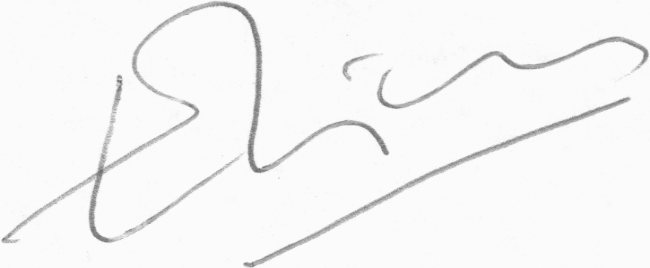

In [ ]:
os.chdir('/content/drive/MyDrive/signature_dataset')
img = cv2.imread('/content/drive/MyDrive/signature_dataset/train/001 (1)/001_01 (1).PNG')
cv2_imshow(img)

In [ ]:
os.chdir('/content/drive/MyDrive/signature_dataset')

In [ ]:
img.shape

(268, 650, 3)

In [ ]:
import numpy as np
def load_images_from_dataset(base_dir):
    orig_images, forg_images = [], []
    for person in sorted(os.listdir(base_dir)):
        person_path = os.path.join(base_dir, person)
        if not os.path.isdir(person_path):
            continue
        for img_name in sorted(os.listdir(person_path)):
            img_path = os.path.join(person_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (650, 268))
            img = np.expand_dims(img, axis=-1)
            img = img.astype('float32') / 255.0
            if 'forg' in person.lower():
                forg_images.append(img)
            else:
                orig_images.append(img)
    return np.array(orig_images), np.array(forg_images)

train_orig, train_forg = load_images_from_dataset('../signature_data_one_shot/train_data')
val_orig, val_forg = load_images_from_dataset('../signature_data_one_shot/validation_data')
test_orig, test_forg = load_images_from_dataset('../signature_data_one_shot/test_data')
print(train_orig.shape, train_forg.shape)
print(val_orig.shape, val_forg.shape)
print(test_orig.shape, test_forg.shape)


(600, 268, 650, 1) (400, 268, 650, 1)
(264, 268, 650, 1) (144, 268, 650, 1)
(204, 268, 650, 1) (168, 268, 650, 1)


In [ ]:
def create_pairs(orig_imgs, forg_imgs):
    pairs = []
    labels = []
    min_count = min(len(orig_imgs), len(forg_imgs))
    # Genuine pairs
    for i in range(min_count - 1):
        pairs.append([orig_imgs[i], orig_imgs[i+1]])
        labels.append(0)
    # Forged pairs
    for i in range(min_count):
        pairs.append([orig_imgs[i], forg_imgs[i]])
        labels.append(1)
    return np.array(pairs), np.array(labels)

train_pairs, train_labels = create_pairs(train_orig, train_forg)
val_pairs, val_labels = create_pairs(val_orig, val_forg)
test_pairs, test_labels = create_pairs(test_orig, test_forg)


In [ ]:
def load_images(path):
    features = []
    labels = []  # 0 for original, 1 for forgery
    for person in sorted(os.listdir(path)):
        folder = os.path.join(path, person)
        for img_name in sorted(os.listdir(folder)):
            img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (650, 268))
            img = img.astype('float32') / 255.0
            features.append(np.expand_dims(img, axis=-1))
            labels.append(0 if 'forg' not in person.lower() else 1)
    return np.array(features), np.array(labels)

train_features, train_labels = load_images('../signature_data_one_shot/train_data')
val_features, val_labels = load_images('../signature_data_one_shot/validation_data')
test_features, test_labels = load_images('../signature_data_one_shot/test_data')

print(train_features.shape, val_features.shape, test_features.shape)

(700, 268, 650, 1) (152, 268, 650, 1) (148, 268, 650, 1)


In [ ]:
def create_pairs(features, labels):
    pairs = []
    pair_labels = []
    num_classes = np.unique(labels)

    class_indices = {cls: np.where(labels == cls)[0] for cls in num_classes}

    for cls in num_classes:
        idx = class_indices[cls]
        # Positive pairs
        for i in range(len(idx)-1):
            pairs.append([features[idx[i]], features[idx[i+1]]])
            pair_labels.append(0)
        # Negative pairs
        other_cls = [c for c in num_classes if c != cls]
        for i in range(len(idx)):
            neg_cls = np.random.choice(other_cls)
            neg_idx = np.random.choice(class_indices[neg_cls])
            pairs.append([features[idx[i]], features[neg_idx]])
            pair_labels.append(1)

    return np.array(pairs), np.array(pair_labels)

train_pairs, train_pair_labels = create_pairs(train_features, train_labels)
val_pairs, val_pair_labels = create_pairs(val_features, val_labels)

print(train_pairs.shape, train_pair_labels.shape)

(1398, 2, 268, 650, 1) (1398,)


In [ ]:
def build_base_network(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    model = models.Model(inp, x)
    return model

In [ ]:
def euclidean_distance(vects):
    x, y = vects
    return tf.sqrt(tf.reduce_sum(tf.square(x - y), axis=1, keepdims=True))

def eucl_dist_output_shape(shapes):
    return (shapes[0][0],1)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

input_shape = (268, 650, 1)

base_network = build_base_network(input_shape)

input_a = layers.Input(shape=input_shape)
input_b = layers.Input(shape=input_shape)

processed_a = base_network(input_a)
processed_b = base_network(input_b)

distance = layers.Lambda(euclidean_distance, output_shape=eucl_dist_output_shape)([processed_a, processed_b])

siamese_model = models.Model([input_a, input_b], distance)
def contrastive_loss(y_true, y_pred, margin=1):
    y_true = tf.cast(y_true, y_pred.dtype)
    return tf.reduce_mean((1 - y_true) * tf.square(y_pred) +
                          y_true * tf.square(tf.maximum(margin - y_pred, 0)))
siamese_model.compile(loss=contrastive_loss, optimizer=optimizers.Adam(0.0001), metrics=['accuracy'])
siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 268, 650,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 268, 650,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 128)       │ 21,953,088 │ input_layer_1[0]… │
│ (Functional)        │                   │            │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ functional[0][0], │
│                     │                   │            │ functional[1][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,953,088 (83.74 MB)

 Trainable params: 21,953,088 (83.74 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
siamese_model.fit(
    [train_pairs[:,0], train_pairs[:,1]], train_labels,
    validation_data=([val_pairs[:,0], val_pairs[:,1]], val_labels),
    batch_size=32,
    epochs=10
)

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 1398, 1398
'y' sizes: 700


In [ ]:
TARGET_HEIGHT = 268
TARGET_WIDTH = 650
import cv2
import numpy as np
import os
from tqdm import tqdm

def load_and_resize_images(folder_path):
    images = []
    for fname in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # convert to grayscale
        if img is None:
            continue  # skip if image is not readable
        # Resize to target size
        img_resized = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT))
        # Add channel dimension for CNN
        img_resized = np.expand_dims(img_resized, axis=-1)
        # Normalize
        img_resized = img_resized.astype('float32') / 255.0
        images.append(img_resized)
    return np.array(images)
import os
import cv2
import numpy as np
from tqdm import tqdm

TARGET_HEIGHT = 268
TARGET_WIDTH = 650

def load_images_from_dataset(base_dir):
    orig_images, forg_images = [], []
    for person in sorted(os.listdir(base_dir)):
        person_path = os.path.join(base_dir, person)
        if not os.path.isdir(person_path):
            continue
        for img_name in sorted(os.listdir(person_path)):
            img_path = os.path.join(person_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT))
            img = np.expand_dims(img, axis=-1)
            img = img.astype('float32') / 255.0
            # Separate original vs forged based on folder name
            if 'forg' in person.lower():
                forg_images.append(img)
            else:
                orig_images.append(img)
    return np.array(orig_images), np.array(forg_images)

# Load train, validation, test
train_orig, train_forg = load_images_from_dataset('../signature_data_one_shot/train_data')
val_orig, val_forg = load_images_from_dataset('../signature_data_one_shot/validation_data')
test_orig, test_forg = load_images_from_dataset('../signature_data_one_shot/test_data')

print(train_orig.shape, train_forg.shape)
print(val_orig.shape, val_forg.shape)
print(test_orig.shape, test_forg.shape)
def create_pairs(orig_imgs, forg_imgs):
    pairs = []
    labels = []

    min_count = min(len(orig_imgs), len(forg_imgs))

    # Genuine pairs: original with original
    for i in range(min_count - 1):
        pairs.append([orig_imgs[i], orig_imgs[i+1]])
        labels.append(0)  # 0 = genuine

    # Forged pairs: original with forged
    for i in range(min_count):
        pairs.append([orig_imgs[i], forg_imgs[i]])
        labels.append(1)  # 1 = forged

    return np.array(pairs), np.array(labels)
train_pairs, train_labels = create_pairs(train_orig, train_forg)
val_pairs, val_labels = create_pairs(val_orig, val_forg)
test_pairs, test_labels = create_pairs(test_orig, test_forg)

print(train_pairs.shape, train_labels.shape)
print(val_pairs.shape, val_labels.shape)
print(test_pairs.shape, test_labels.shape)
siamese_model.fit(
    [train_pairs[:,0], train_pairs[:,1]], train_labels,
    validation_data=([val_pairs[:,0], val_pairs[:,1]], val_labels),
    batch_size=32,
    epochs=10
)

(420, 268, 650, 1) (280, 268, 650, 1)
(96, 268, 650, 1) (56, 268, 650, 1)
(84, 268, 650, 1) (64, 268, 650, 1)
(559, 2, 268, 650, 1) (559,)
(111, 2, 268, 650, 1) (111,)
(127, 2, 268, 650, 1) (127,)
Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 31s 966ms/step - accuracy: 0.5642 - loss: 0.3064 - val_accuracy: 0.8468 - val_loss: 0.1147
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 299ms/step - accuracy: 0.9362 - loss: 0.0736 - val_accuracy: 0.8649 - val_loss: 0.1090
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 315ms/step - accuracy: 0.9822 - loss: 0.0323 - val_accuracy: 0.8739 - val_loss: 0.1101
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 305ms/step - accuracy: 0.9965 - loss: 0.0177 - val_accuracy: 0.8559 - val_loss: 0.1117
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 302ms/step - accuracy: 1.0000 - loss: 0.0119 - val_accuracy: 0.8559 - val_loss: 0.1118
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 305ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 0.8829 - val_loss: 0.1088
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = siamese_model.evaluate([test_pairs[:,0], test_pairs[:,1]], test_labels)
print("Test Loss:", test_loss)
print("Test Accuracy:",test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9193 - loss: 0.0940
Test Loss: 0.11718486994504929
Test Accuracy: 0.8582677245140076


In [ ]:
# Create pairs function
def create_pairs(orig_imgs, forg_imgs):
    pairs = []
    labels = []

    min_count = min(len(orig_imgs), len(forg_imgs))

    # Genuine pairs: original with original
    for i in range(min_count - 1):
        pairs.append([orig_imgs[i], orig_imgs[i+1]])
        labels.append(0)  # 0 = genuine

    # Forged pairs: original with forged
    for i in range(min_count):
        pairs.append([orig_imgs[i], forg_imgs[i]])
        labels.append(1)  # 1 = forged

    return np.array(pairs), np.array(labels)

# Create test pairs
test_pairs, test_labels = create_pairs(test_orig, test_forg)
print("Test pairs:", test_pairs.shape)
print("Test labels:", test_labels.shape)

# Evaluate the model
test_loss, test_acc = siamese_model.evaluate([test_pairs[:,0], test_pairs[:,1]], test_labels)
print("Test Loss:", test_loss)
print("Test Accuracy:",test_acc)

Test pairs: (127, 2, 268, 650, 1)
Test labels: (127,)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9193 - loss: 0.0940
Test Loss: 0.11718486994504929
Test Accuracy: 0.8582677245140076


In [ ]:
# Save in Keras 3 format
siamese_model.save("siamese_model_9.keras")


In [ ]:
# Save the model to a .h5 file
siamese_model.save('siamese_model_9.h5')

In [ ]:
# 1️⃣ Upload files
from google.colab import files

print("Upload reference signature")
ref_file = files.upload()  # choose reference image

print("Upload test signature")
test_file = files.upload()  # choose signature to verify


Upload reference signature


Saving 01_064.png to 01_064 (1).png
Upload test signature


Saving 05_064.png to 05_064.png


Model loaded ✅
Upload reference signature:


Saving 01_069 (1).png to 01_069 (1) (2).png
Upload test signature:


Saving 01_0106069 (1).PNG to 01_0106069 (1) (1).PNG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
Verification Result: Forged, Distance Score: 0.8650


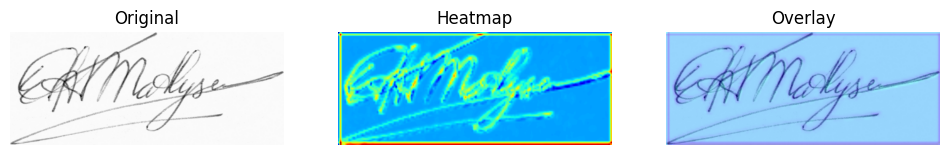

In [ ]:
# =========================
# 1️⃣ Install & Import
# =========================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# =========================
# 2️⃣ Custom Functions
# =========================

# 2a. Euclidean distance for Siamese network
def euclidean_distance(vects):
    x, y = vects
    return tf.sqrt(tf.reduce_sum(tf.square(x - y), axis=1, keepdims=True))

def eucl_dist_output_shape(shapes):
    return (shapes[0][0], 1)

# 2b. Preprocess uploaded images
TARGET_HEIGHT = 268
TARGET_WIDTH = 650

def preprocess_signature(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT))
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)       # channel
    img = np.expand_dims(img, axis=0)        # batch
    return img

# 2c. Verification function
def verify_signature(ref_img_path, test_img_path, threshold=0.5):
    ref_img = preprocess_signature(ref_img_path)
    test_img = preprocess_signature(test_img_path)

    distance = siamese_model.predict([ref_img, test_img])[0][0]

    if distance < threshold:
        result = "Genuine"
    else:
        result = "Forged"

    return result, distance

# 2d. Grad-CAM
def get_last_conv_layer(model):
    # Access base network
    base_network = model.get_layer("functional")
    for layer in reversed(base_network.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

def grad_cam(model, img, layer_name=None):
    base_network = model.get_layer("functional")
    if layer_name is None:
        layer_name = get_last_conv_layer(model)
    last_conv_layer = base_network.get_layer(layer_name)

    grad_model = tf.keras.models.Model(
        [base_network.inputs],
        [last_conv_layer.output, base_network.output]
    )

    img = np.expand_dims(img, axis=0)  # add batch

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-10
    return heatmap

# 2e. Overlay heatmap
def display_gradcam(img, heatmap, alpha=0.4):
    """
    img: original preprocessed image (H,W,1)
    heatmap: Grad-CAM heatmap (H,W)
    alpha: blending factor
    """

    # Resize heatmap to match original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to uint8
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # Ensure original image is 3-channel and uint8
    if img.shape[-1] == 1:
        img_rgb = cv2.cvtColor(np.uint8(img * 255), cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = np.uint8(img * 255)

    # Overlay heatmap on original image
    superimposed_img = cv2.addWeighted(img_rgb, 1-alpha, heatmap_color, alpha, 0)

    # Show result
    plt.figure(figsize=(12,5))
    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Heatmap")
    plt.imshow(heatmap, cmap="jet")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(superimposed_img)
    plt.axis("off")

    plt.show()


# =========================
# 3️⃣ Load Trained Model
# =========================
siamese_model = load_model(
    "siamese_model_9.keras",
    compile=False,
    custom_objects={
        "euclidean_distance": euclidean_distance,
        "eucl_dist_output_shape": eucl_dist_output_shape
    }
)
print("Model loaded ✅")

# =========================
# 4️⃣ Upload Files
# =========================
print("Upload reference signature:")
ref_file = files.upload()  # choose reference image

print("Upload test signature:")
test_file = files.upload()  # choose signature to verify

ref_path = list(ref_file.keys())[0]
test_path = list(test_file.keys())[0]

# =========================
# 5️⃣ Verification
# =========================
result, score = verify_signature(ref_path, test_path)
print(f"Verification Result: {result}, Distance Score: {score:.4f}")

# =========================
# 6️⃣ Grad-CAM Visualization
# =========================
# Preprocess for Grad-CAM (remove batch dimension)
ref_img = preprocess_signature(ref_path)[0]
test_img = preprocess_signature(test_path)[0]

heatmap = grad_cam(siamese_model, test_img)
display_gradcam(test_img, heatmap)


In [ ]:
# 2️⃣ Imports and constants
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

TARGET_HEIGHT = 268
TARGET_WIDTH = 650


In [ ]:
# 3️⃣ Preprocess function
def preprocess_signature(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (TARGET_WIDTH, TARGET_HEIGHT))
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)  # add channel
    img = np.expand_dims(img, axis=0)   # add batch dimension
    return img


In [ ]:

import tensorflow as tf
from keras.models import load_model

# Re-define custom functions
def euclidean_distance(vects):
    x, y = vects
    return tf.sqrt(tf.reduce_sum(tf.square(x - y), axis=1, keepdims=True))

def eucl_dist_output_shape(shapes):
    return (shapes[0][0], 1)

def contrastive_loss(y_true, y_pred, margin=1):
    y_true = tf.cast(y_true, y_pred.dtype)
    return tf.reduce_mean(
        (1 - y_true) * tf.square(y_pred) +
        y_true * tf.square(tf.maximum(margin - y_pred, 0))
    )

# Load model with custom_objects
siamese_model = load_model(
    "siamese_model_9.keras",  # or .h5 if you saved in that format
    custom_objects={
        "euclidean_distance": euclidean_distance,
        "eucl_dist_output_shape": eucl_dist_output_shape,
        "contrastive_loss": contrastive_loss
    },
    compile=False
)

# Compile after loading
siamese_model.compile(
    loss=contrastive_loss,
    optimizer=tf.keras.optimizers.Adam(0.0001),
    metrics=["accuracy"]
)

print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [ ]:
# 5️⃣ Verification function
def verify_signature(ref_img_path, test_img_path, threshold=0.5):
    ref_img = preprocess_signature(ref_img_path)
    test_img = preprocess_signature(test_img_path)

    distance = siamese_model.predict([ref_img, test_img])[0][0]

    if distance < threshold:
        result = "Genuine"
    else:
        result = "Forged"

    return result, distance


In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_last_conv_layer(model):
    # Find last Conv2D layer in the base network
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

def grad_cam(model, img, layer_name="conv2d_2"):
    # Access base network
    base_network = model.get_layer("functional")
    last_conv_layer = base_network.get_layer(layer_name)

    # Model: input -> last conv layer + output
    grad_model = tf.keras.models.Model(
        [base_network.inputs],
        [last_conv_layer.output, base_network.output]
    )

    # Ensure input has batch dimension
    img = np.expand_dims(img, axis=0)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        loss = predictions  # you can use predictions[0,0] if scalar

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-10)
    return heatmap



def overlay_heatmap(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    overlayed = cv2.addWeighted(cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), alpha, heatmap, 1-alpha, 0)
    return overlayed


In [ ]:
import cv2
import matplotlib.pyplot as plt

def display_gradcam(img, heatmap, alpha=0.4):
    """
    img: original preprocessed image (H,W,1)
    heatmap: Grad-CAM heatmap (H,W)
    alpha: blending factor
    """

    # Resize heatmap to match original image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert to RGB
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Ensure original image is 3-channel for blending
    if img.shape[-1] == 1:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = img

    # Overlay heatmap on original image
    superimposed_img = cv2.addWeighted(img_rgb, 1-alpha, heatmap_color, alpha, 0)

    # Show result
    plt.figure(figsize=(10,5))
    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img_rgb, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Heatmap")
    plt.imshow(heatmap, cmap="jet")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(superimposed_img)
    plt.axis("off")

    plt.show()


In [ ]:
# 7️⃣ Run verification
ref_path = list(ref_file.keys())[0]
test_path = list(test_file.keys())[0]

result, score = verify_signature(ref_path, test_path)
print(f"Result: {result}, Distance Score: {score}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Result: Genuine, Distance Score: 0.23811712861061096
